In [3]:
# ============================================================
# PROJECT 1 — Zomato Restaurant EDA
# Author: Rohit Mane
# Dataset: Zomato Restaurants Dataset (Kaggle)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="darkgrid")

# Load dataset
df = pd.read_csv('/zomato.csv', encoding='latin-1')

# Basic inspection
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (9551, 21)

Columns:
 ['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

Data Types:
 Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating t

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
# ============================================================
# STEP 1 — Data Inspection
# ============================================================

print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Rows ===")
print(df.duplicated().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Missing Values ===
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

=== Duplicate Rows ===
0

=== Basic Statistics ===


,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [5]:
# ============================================================
# STEP 2 — Data Cleaning
# ============================================================

# 1. Drop rows with missing Cuisines (only 9 rows — safe to drop)
df = df.dropna(subset=['Cuisines'])
print("Rows after dropping missing Cuisines:", len(df))

# 2. Drop irrelevant columns (IDs, verbose duplicates, coordinates)
cols_to_drop = ['Restaurant ID', 'Address', 'Locality Verbose',
                'Longitude', 'Latitude', 'Switch to order menu',
                'Rating color']
df = df.drop(columns=cols_to_drop)
print("Columns after dropping irrelevant ones:", df.shape[1])

# 3. Rename columns for easier use
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()
print("\nCleaned Column Names:\n", df.columns.tolist())

# 4. Filter only India data (Country Code 1 = India) for focused analysis
df_india = df[df['country_code'] == 1].copy()
print("\nIndia restaurants count:", len(df_india))

# 5. Final check
print("\nFinal Dataset Shape:", df_india.shape)
print("\nMissing Values After Cleaning:")
print(df_india.isnull().sum())

Rows after dropping missing Cuisines: 9542
Columns after dropping irrelevant ones: 14

Cleaned Column Names:
 ['restaurant_name', 'country_code', 'city', 'locality', 'cuisines', 'average_cost_for_two', 'currency', 'has_table_booking', 'has_online_delivery', 'is_delivering_now', 'price_range', 'aggregate_rating', 'rating_text', 'votes']

India restaurants count: 8652

Final Dataset Shape: (8652, 14)

Missing Values After Cleaning:
restaurant_name         0
country_code            0
city                    0
locality                0
cuisines                0
average_cost_for_two    0
currency                0
has_table_booking       0
has_online_delivery     0
is_delivering_now       0
price_range             0
aggregate_rating        0
rating_text             0
votes                   0
dtype: int64


In [6]:
# ============================================================
# STEP 3 — Exploratory Data Analysis (5 Questions)
# ============================================================

# Q1. Which cities have the most restaurants on Zomato?
print("=== Q1: Top 10 Cities by Restaurant Count ===")
q1 = df_india['city'].value_counts().head(10)
print(q1)

# Q2. What is the most popular cuisine in India on Zomato?
print("\n=== Q2: Top 10 Cuisines ===")
q2 = df_india['cuisines'].value_counts().head(10)
print(q2)

# Q3. What percentage of restaurants offer online delivery?
print("\n=== Q3: Online Delivery Distribution ===")
q3 = df_india['has_online_delivery'].value_counts(normalize=True) * 100
print(q3.round(2))

# Q4. What is the average rating by price range?
print("\n=== Q4: Average Rating by Price Range ===")
q4 = df_india.groupby('price_range')['aggregate_rating'].mean().round(2)
print(q4)

# Q5. What is the average cost for two by city (Top 10)?
print("\n=== Q5: Average Cost for Two by City (Top 10 costliest) ===")
q5 = df_india.groupby('city')['average_cost_for_two'].mean().sort_values(ascending=False).head(10)
print(q5.round(2))

=== Q1: Top 10 Cities by Restaurant Count ===
city
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Guwahati          21
Lucknow           21
Bhubaneshwar      21
Ahmedabad         21
Amritsar          21
Name: count, dtype: int64

=== Q2: Top 10 Cuisines ===
cuisines
North Indian                      936
North Indian, Chinese             511
Fast Food                         348
Chinese                           340
North Indian, Mughlai             334
Cafe                              279
Bakery                            216
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

=== Q3: Online Delivery Distribution ===
has_online_delivery
No     71.99
Yes    28.01
Name: proportion, dtype: float64

=== Q4: Average Rating by Price Range ===
price_range
1    1.93
2    2.86
3    3.57
4    3.63
Name: aggregate_rating, dtype: float64

=== Q5: Avera

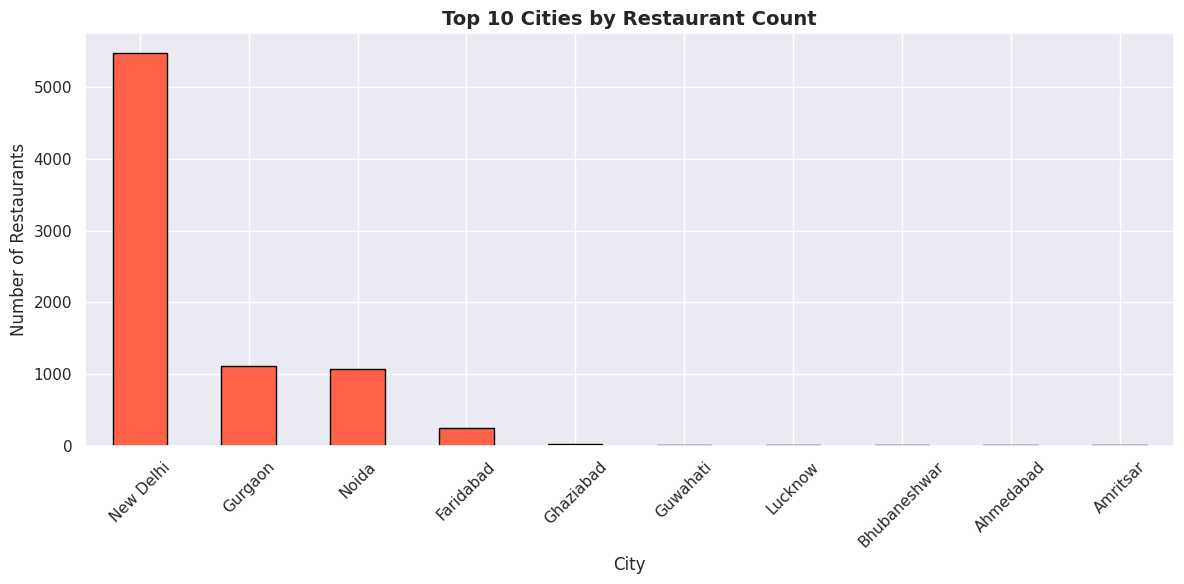

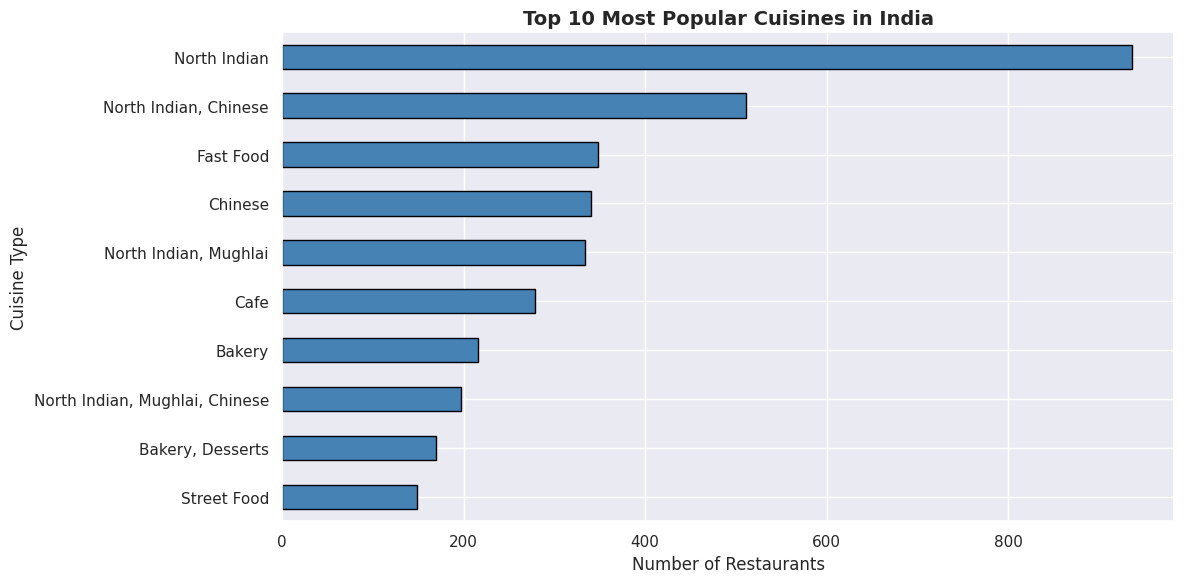

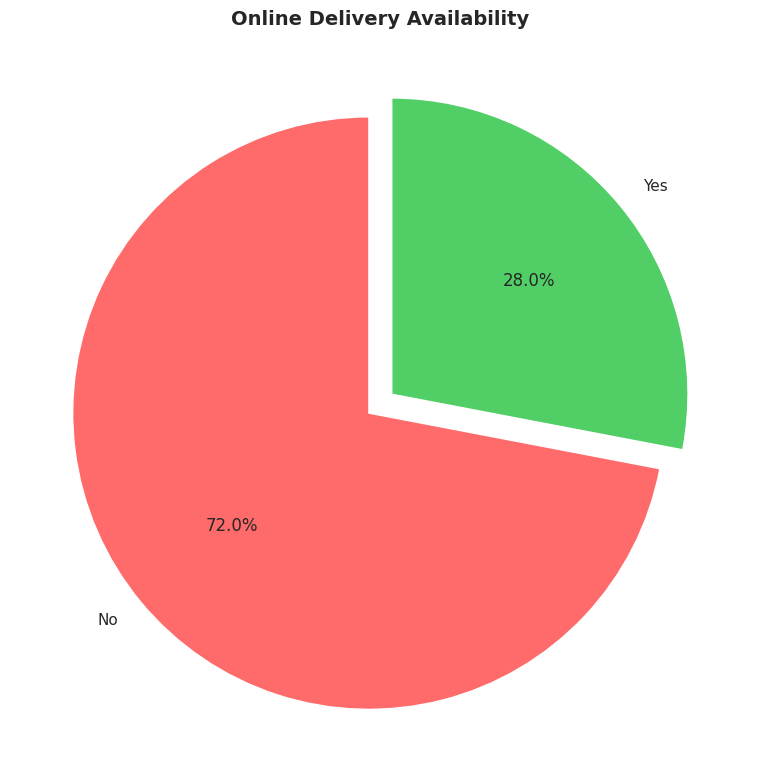

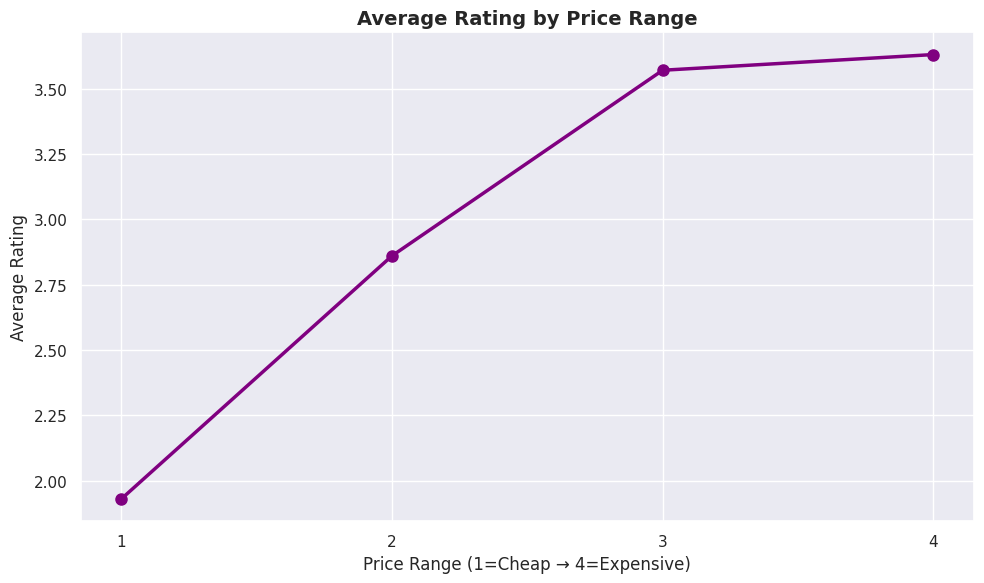

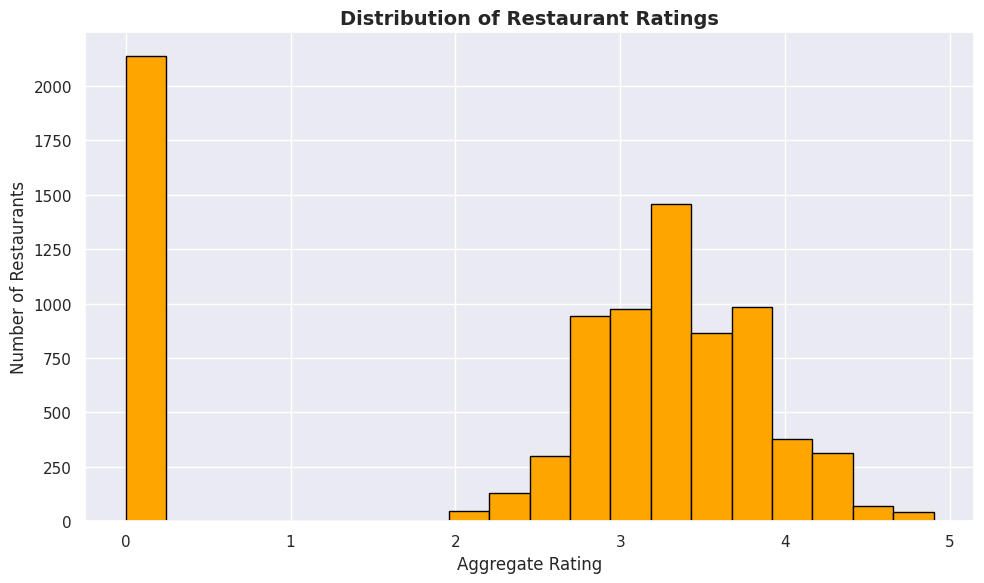

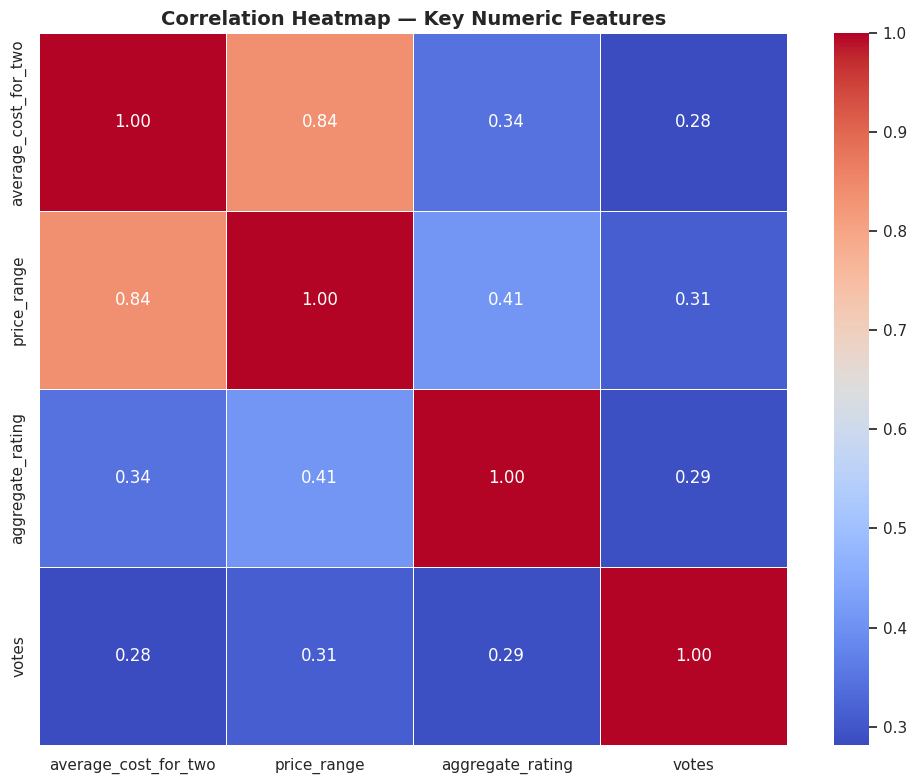

All 6 charts generated successfully!


In [8]:
# ============================================================
# STEP 4 — Visualizations (6 Charts — Individual)
# ============================================================

# Chart 1 — BAR CHART: Top 10 Cities by Restaurant Count
plt.figure(figsize=(12, 6))
q1.plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Top 10 Cities by Restaurant Count', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 2 — HORIZONTAL BAR: Top 10 Cuisines
plt.figure(figsize=(12, 6))
q2.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 10 Most Popular Cuisines in India', fontsize=14, fontweight='bold')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine Type')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Chart 3 — PIE CHART: Online Delivery Distribution
plt.figure(figsize=(8, 8))
q3.plot(kind='pie', autopct='%1.1f%%', colors=['#ff6b6b', '#51cf66'],
        startangle=90, explode=(0.05, 0.05))
plt.title('Online Delivery Availability', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Chart 4 — LINE CHART: Avg Rating by Price Range
plt.figure(figsize=(10, 6))
q4.plot(kind='line', marker='o', color='purple', linewidth=2.5, markersize=8)
plt.title('Average Rating by Price Range', fontsize=14, fontweight='bold')
plt.xlabel('Price Range (1=Cheap → 4=Expensive)')
plt.ylabel('Average Rating')
plt.xticks([1, 2, 3, 4])
plt.tight_layout()
plt.show()

# Chart 5 — HISTOGRAM: Distribution of Ratings
plt.figure(figsize=(10, 6))
df_india['aggregate_rating'].hist(bins=20, color='orange', edgecolor='black')
plt.title('Distribution of Restaurant Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Aggregate Rating')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()

# Chart 6 — HEATMAP: Correlation Matrix
plt.figure(figsize=(10, 8))
numeric_cols = df_india[['average_cost_for_two', 'price_range', 'aggregate_rating', 'votes']]
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Key Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("All 6 charts generated successfully!")

In [9]:
# ============================================================
# STEP 5 — Insights Report
# ============================================================

insights = """
ZOMATO INDIA — 5 KEY BUSINESS INSIGHTS
========================================

INSIGHT 1: New Delhi Dominates India's Food Delivery Market
New Delhi alone has 5,473 restaurants — nearly 5x more than Gurgaon (1,118)
and Noida (1,080). This extreme concentration suggests Zomato's business is
heavily dependent on the NCR region. Expanding aggressively to Tier-2 cities
like Lucknow, Ahmedabad, and Bhubaneswar (only 21 restaurants each) presents
a massive untapped growth opportunity.
[Reference: Chart 1 — Top 10 Cities by Restaurant Count]

INSIGHT 2: North Indian Cuisine is India's Undisputed King
North Indian cuisine (936 restaurants) is the single most listed cuisine,
followed by North Indian + Chinese combos (511). This tells us that fusion
menus combining North Indian with Chinese are extremely popular — restaurants
offering this combo likely attract a wider customer base.
[Reference: Chart 2 — Top 10 Most Popular Cuisines]

INSIGHT 3: 72% of Restaurants Still Don't Offer Online Delivery
Despite the food delivery boom, 72% of Zomato-listed Indian restaurants have
no online delivery. This is a massive business gap — Zomato can aggressively
onboard these restaurants onto delivery to significantly grow its GMV and
revenue from commissions.
[Reference: Chart 3 — Online Delivery Availability]

INSIGHT 4: Higher Price = Higher Rating — Customers Pay for Quality
There is a clear positive trend between price range and aggregate rating.
Budget restaurants (price range 1) average only 1.93 stars, while premium
restaurants (price range 4) average 3.63 stars. This shows customers at
premium restaurants are more satisfied — Zomato should highlight premium
restaurants more prominently to improve platform-wide ratings.
[Reference: Chart 4 — Average Rating by Price Range]

INSIGHT 5: Most Restaurants Are Either Unrated or Rated Between 3.0–4.5
The ratings histogram shows a large spike at 0 (unrated restaurants) and a
healthy cluster between 3.0 and 4.5. Very few restaurants achieve above 4.5.
Zomato should incentivize customers of unrated restaurants to leave reviews —
this would improve data quality and help users make better dining decisions.
[Reference: Chart 5 — Distribution of Restaurant Ratings]

========================================
MOST SURPRISING FINDING:
The finding that surprised me most was that 72% of Zomato-listed restaurants
in India still do not offer online delivery (Insight 3). Given how dominant
food delivery apps are in India today, I expected this number to be much lower.
This gap shows there is still enormous room for growth in Zomato's core
delivery business, especially in cities outside NCR.
========================================
"""

print(insights)


ZOMATO INDIA — 5 KEY BUSINESS INSIGHTS

INSIGHT 1: New Delhi Dominates India's Food Delivery Market
New Delhi alone has 5,473 restaurants — nearly 5x more than Gurgaon (1,118)
and Noida (1,080). This extreme concentration suggests Zomato's business is
heavily dependent on the NCR region. Expanding aggressively to Tier-2 cities
like Lucknow, Ahmedabad, and Bhubaneswar (only 21 restaurants each) presents
a massive untapped growth opportunity.
[Reference: Chart 1 — Top 10 Cities by Restaurant Count]

INSIGHT 2: North Indian Cuisine is India's Undisputed King
North Indian cuisine (936 restaurants) is the single most listed cuisine,
followed by North Indian + Chinese combos (511). This tells us that fusion
menus combining North Indian with Chinese are extremely popular — restaurants
offering this combo likely attract a wider customer base.
[Reference: Chart 2 — Top 10 Most Popular Cuisines]

INSIGHT 3: 72% of Restaurants Still Don't Offer Online Delivery
Despite the food delivery boom, 72%